You will analyze a dataset of the global average sea level change since 1880. You will use the data to predict the sea level change through year 2050.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

Use Pandas to import the data from `epa-sea-level.csv`.

In [2]:
df = pd.read_csv("epa-sea-level.csv")
df.head()

,Year,CSIRO Adjusted Sea Level,Lower Error Bound,Upper Error Bound,NOAA Adjusted Sea Level
0,1880,0.000000,-0.952756,0.952756,NaN
1,1881,0.220472,-0.732283,1.173228,NaN
2,1882,-0.440945,-1.346457,0.464567,NaN
3,1883,-0.232283,-1.129921,0.665354,NaN
4,1884,0.590551,-0.283465,1.464567,NaN


Use matplotlib to create a scatter plot using the `Year` column as the x-axis and the `CSIRO Adjusted Sea Level` column as the y-axis.

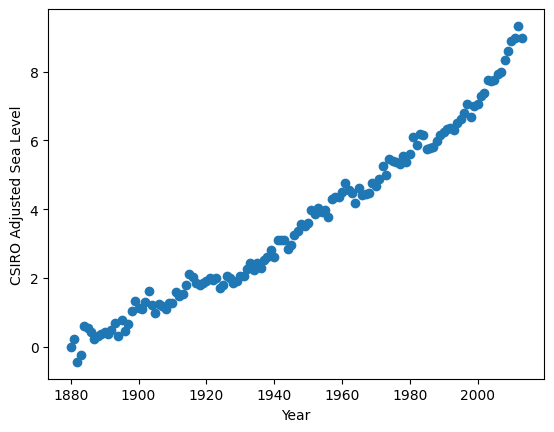

In [57]:
plt.scatter(df["Year"], df["CSIRO Adjusted Sea Level"])
plt.xlabel("Year")
plt.ylabel("CSIRO Adjusted Sea Level")
plt.show()

Use the `linregress` function from `scipy.stats` to get the slope and y-intercept of the line of best fit. Plot the line of best fit over the top of the scatter plot. Make the line go through the year 2050 to predict the sea level rise in 2050.

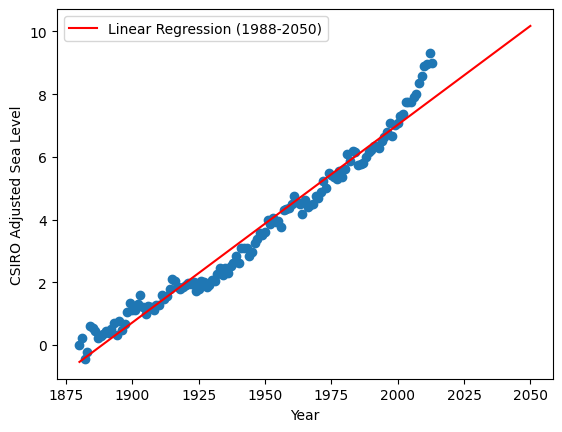

In [56]:
linear_regression = linregress(df["Year"], df["CSIRO Adjusted Sea Level"])

future_years = pd.Series(range(df['Year'].min(), 2051))
y_pred = linear_regression.slope * future_years + linear_regression.intercept

plt.scatter(df["Year"], df["CSIRO Adjusted Sea Level"])
plt.plot(future_years, y_pred, color="red", label="Linear Regression (1988-2050)")
plt.xlabel("Year")
plt.ylabel("CSIRO Adjusted Sea Level")
plt.legend()
plt.show()

Plot a new line of best fit just using the data from year 2000 through the most recent year in the dataset. Make the line also go through the year 2050 to predict the sea level rise in 2050 if the rate of rise continues as it has since the year 2000.

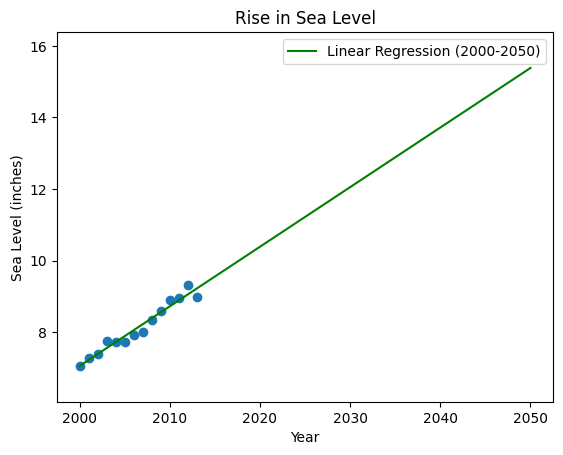

In [55]:
df_updated = df[df["Year"] >= 2000]
linear_regression = linregress(df_updated["Year"], df_updated["CSIRO Adjusted Sea Level"])

future_years = pd.Series(range(df_updated['Year'].min(), 2051))
y_pred = linear_regression.slope * future_years + linear_regression.intercept

plt.scatter(df_updated["Year"], df_updated["CSIRO Adjusted Sea Level"])
plt.plot(future_years, y_pred, color="green", label="Linear Regression (2000-2050)")
plt.xlabel("Year")
plt.ylabel("Sea Level (inches)")
plt.title("Rise in Sea Level")
plt.ylim(df_updated['CSIRO Adjusted Sea Level'].min() - 1 , y_pred.max() + 1)
plt.legend()
plt.show()